# 🚢 Titanic Survival Prediction

This notebook presents a **cleaned-up and bug-fixed Titanic survival prediction pipeline** using **Logistic Regression** and Scikit-learn.

```text
Raw Data
   ↓
Missing Value Imputation
   ↓
Categorical Encoding
   ↓
Feature Scaling
   ↓
Power Transformation
   ↓
Logistic Regression
```

---

### Complete Model Evaluation

The notebook evaluates the model on the **held-out test set** using:

* **Accuracy**
* **Classification Report**
* **Confusion Matrix**

---

## 🎯 Final Pipeline

The corrected workflow can be summarized as:

```text
                    Titanic Dataset
                           │
                           ▼
                    Train / Test Split
                           │
              ┌────────────┴────────────┐
              ▼                         ▼
           X_train                   X_test
              │                         │
              ▼                         │
        Preprocessing                   │
              │                         │
      ┌───────┴────────┐                │
      ▼                ▼                │
 Numerical         Categorical          │
 Features          Features             │
      │                │                │
      ▼                ▼                │
 Imputation        Imputation           │
      │                │                │
      ▼                ▼                │
 Power            One-Hot               │
 Transform        Encoding              │
      │                │                │
      └───────┬────────┘                │
              ▼                         │
           Scaling                      │
              │                         │
              ▼                         │
      Logistic Regression ◄─────────────┘
              │
              ▼
         Predictions
              │
              ▼
     Model Evaluation
```


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Load DataUsing the built-in Seaborn `titanic` dataset.

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Initial EDACheck shape, duplicates, and missing values before touching anything.

In [3]:
df.shape

(891, 15)

In [4]:
# Note: this dataset has no passenger ID/name column, so "duplicates" here means rows# that match on every remaining column simultaneously. Worth a manual spot-check since# NaN == NaN counts as a match for .duplicated(), which can inflate the count when a# column like `deck` is mostly missing.df.duplicated().sum()

In [5]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64

## 4. Feature Selection — Drop Leakage & Redundant Columns

Keep only the first 8 columns to remove features that could introduce **target leakage** or provide redundant information.

* **`alive`** — directly represents the target variable (`survived`) and therefore causes **target leakage**.
* **`who`** — redundant representation of passenger demographics already captured by other features.
* **`class`** — duplicates the information represented by `pclass`.
* **`deck`** — contains substantial missing values.
* **`embark_town`** — duplicates the information represented by `embarked`.

This leaves a more appropriate set of features for model training while avoiding redundant or potentially problematic variables.


In [7]:
df = df.iloc[:, :8]
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 5. Train/Test Split

Split the dataset into training and test sets **before applying any preprocessing**, including imputation, encoding, scaling, or transformation.

This prevents **data leakage**, ensuring that preprocessing parameters are learned only from the training data and then applied to the unseen test data.

The target variable `y` is kept as a **1D Pandas Series** using single brackets:

```python
y = df['survived']
```

rather than:

```python
y = df[['survived']]
```

Using a 1D target avoids unnecessary shape-related warnings, such as `DataConversionWarning`, when fitting the classification model.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(    
    df.drop(columns=['survived']),    
    df['survived'],   # Series, not DataFrame    
    test_size=0.2,    
    random_state=42
)
X_train.shape, y_train.shape

((627, 7), (627,))

In [9]:
X_train

,pclass,sex,age,sibsp,parch,fare,embarked
864,2,male,24.0,0,0,13.0000,S
141,3,female,22.0,0,0,7.7500,S
730,1,female,29.0,0,0,211.3375,S
56,2,female,21.0,0,0,10.5000,S
451,3,male,NaN,1,0,19.9667,S
...,...,...,...,...,...,...,...
72,2,male,21.0,0,0,73.5000,S
112,3,male,22.0,0,0,8.0500,S
287,3,male,22.0,0,0,7.8958,S
482,3,male,50.0,0,0,8.0500,S


## 6. Preprocessing Steps

The preprocessing workflow follows the three-stage sequence:

**Imputation → One-Hot Encoding → Scaling**

In [10]:
trf1 = make_column_transformer(    
    (SimpleImputer(), [2]),    
    (SimpleImputer(strategy='most_frequent'), [6]),    
    remainder='passthrough',    
    verbose_feature_names_out=False
)
trf2 = make_column_transformer(    
    (OneHotEncoder(sparse_output=False, dtype=np.int64, drop='first'), [1, 3]),
    remainder='passthrough',    
    verbose_feature_names_out=False
)
trf3 = make_column_transformer(    
    (MinMaxScaler(), slice(0,9)),    
    remainder='passthrough',    
    verbose_feature_names_out=False
)

## 7. Check Column Order Before Selecting Skew-Fix Columns

Before applying the skewness transformation, fit the preprocessing chain up to this stage and inspect the **actual transformed column indexes**.

```python
X_train_preprocessed = preprocessor.fit_transform(X_train)

print(X_train_preprocessed.columns.tolist())
```

This step is important because `OneHotEncoder` creates new columns and can change the structure of the feature set. 

`PowerTransformer` (Yeo-Johnson) to be applied to on skewed numerical features:

```text
Age
SibSp
Parch
Fare
```

Inspecting the resulting column names first makes feature selection explicit and prevents accidental transformations caused by changes in column order.


In [11]:
from sklearn.pipeline import make_pipeline
preview_pipe = make_pipeline(trf1, trf2, trf3)
preview_out = preview_pipe.fit_transform(X_train)

In [12]:
preview_out

array([[0.        , 1.        , 1.        , ..., 0.        , 0.        ,
        0.02537431],
       [0.        , 1.        , 0.        , ..., 0.        , 0.        ,
        0.01512699],
       [0.        , 1.        , 0.        , ..., 0.        , 0.        ,
        0.41250333],
       ...,
       [0.        , 1.        , 1.        , ..., 0.        , 0.        ,
        0.01541158],
       [0.        , 1.        , 1.        , ..., 0.        , 0.        ,
        0.01571255],
       [0.        , 1.        , 1.        , ..., 0.        , 0.        ,
        0.01541158]], shape=(627, 8))

## 8. Visualize Feature Distributions

Plot the **KDE distribution of each feature** after imputation, one-hot encoding, and scaling.

The purpose of this step is to visually inspect the resulting distributions and identify numerical features that remain **substantially skewed** and may benefit from a skew-correcting transformation such as **Yeo-Johnson**.

```python
for col in X_train_preprocessed.columns:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(X_train_preprocessed[col], fill=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.show()
```

This inspection helps distinguish between:

* **Numerical features** that may benefit from a power transformation.
* **Binary one-hot encoded features**, which generally should **not** be power-transformed.
* Features whose distributions are already reasonably symmetric and therefore may not require additional transformation.

> **Note:** Scaling does not necessarily remove skewness. A feature can have mean 0 and standard deviation 1 while still being strongly right- or left-skewed.


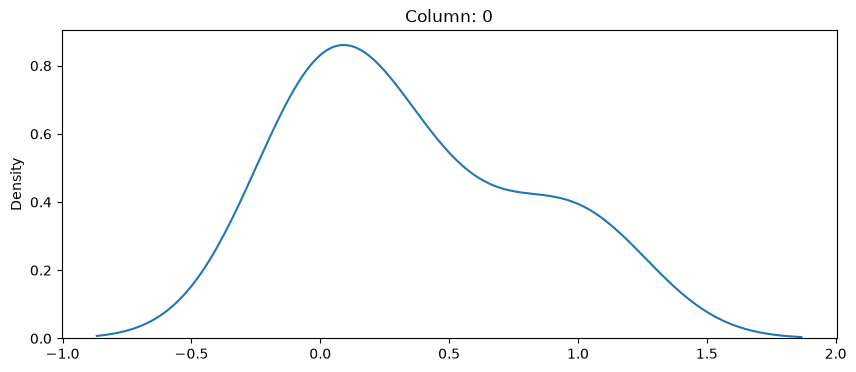

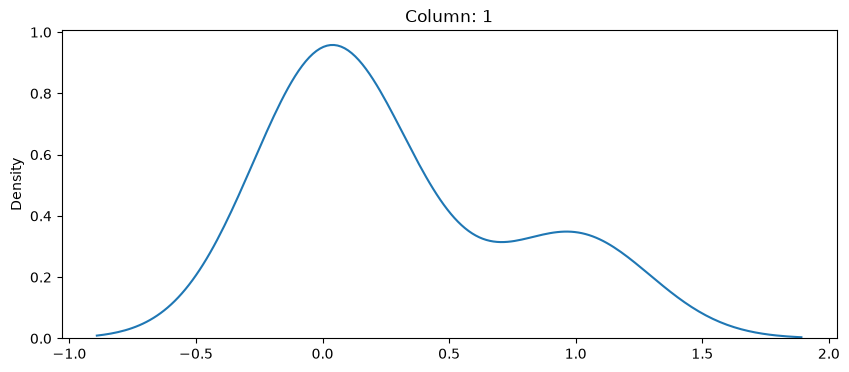

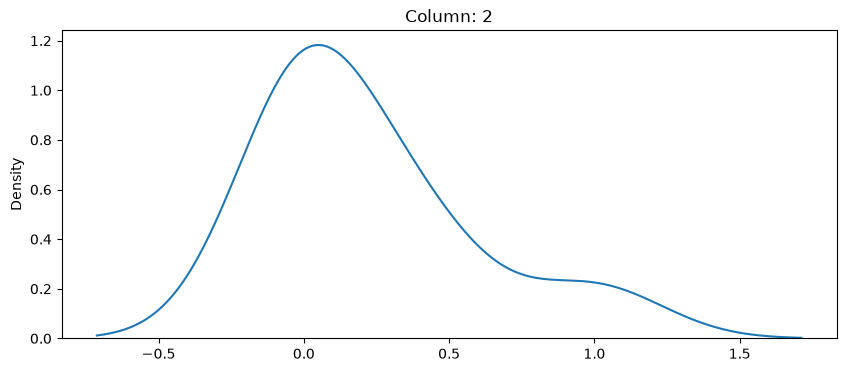

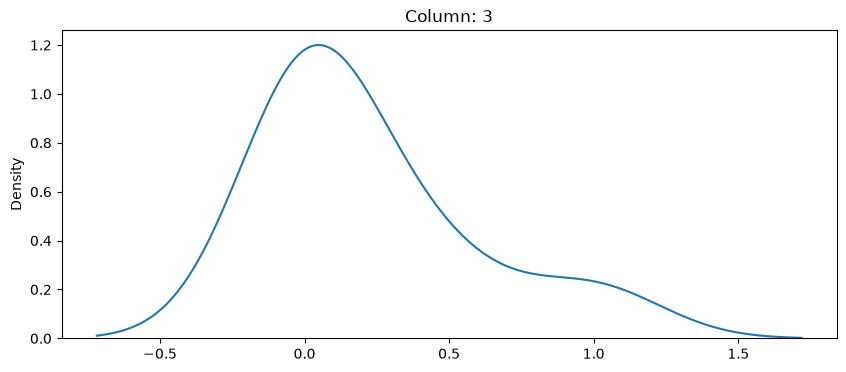

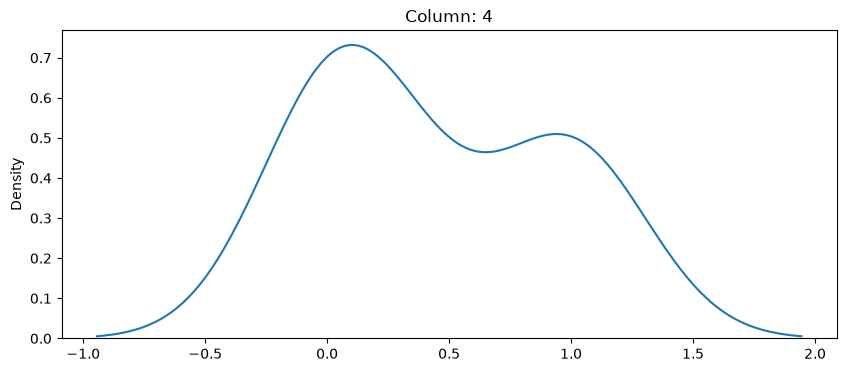

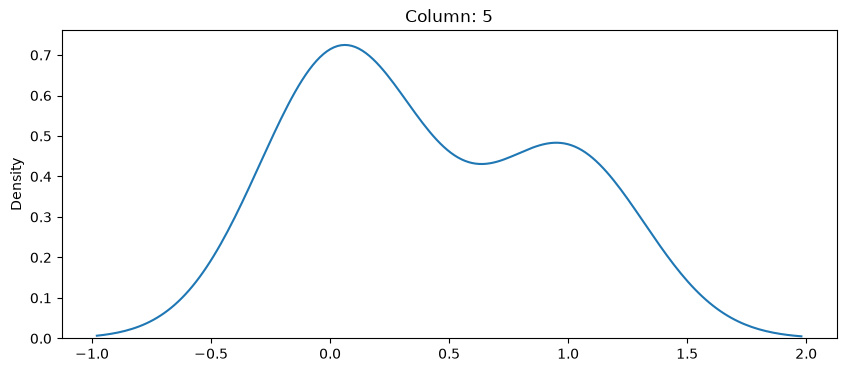

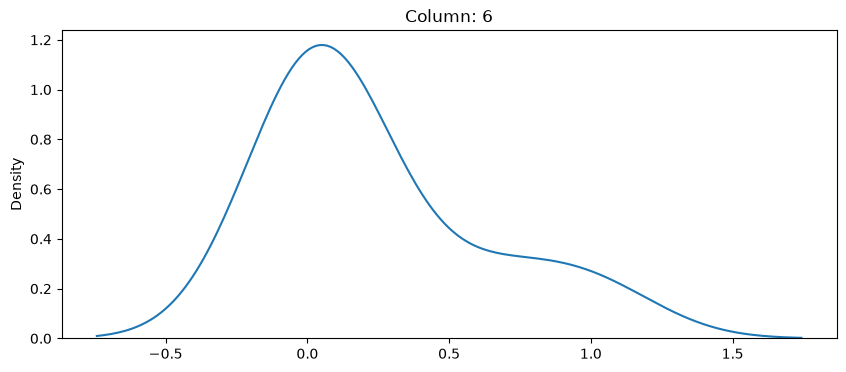

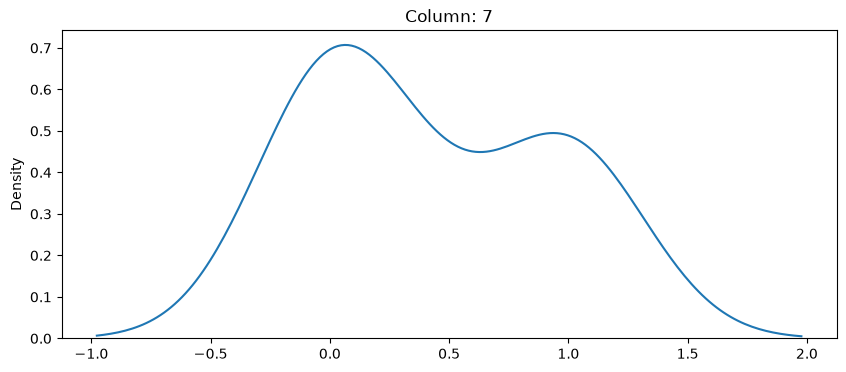

In [13]:
for col in pd.DataFrame(preview_out).columns:    
    plt.figure(figsize=(10, 4))    
    sns.kdeplot(preview_out[col])    
    plt.title(f'Column: {col}')    
    plt.show()

# age, sibsp, parch, fare -> right skewed (continuous/count features)
# the one-hot dummy columns (sex_male, embarked_Q, embarked_S) are binary,
# not continuous, so a "skew" transform doesn't meaningfully apply to them
# even if their KDE curve visually resembles a long tail.

## 9. Full Pipeline — Preprocessing + Skew Correction + Model

All preprocessing and modeling steps are combined into a single `sklearn.Pipeline`, including:

**Imputation → One-Hot Encoding → Scaling → Power Transformation → Logistic Regression**

This is the key structural improvement in the pipeline. By keeping preprocessing and model training together, the same transformation logic is consistently applied during training and inference.

When `Pipeline.fit()` is called on the training data, each preprocessing step learns its parameters **only from the training data**. When `Pipeline.predict()` is called on the test data, the already-fitted transformers are used to transform the test data without re-fitting them.

This prevents accidental data leakage caused by independently calling `fit()` or `fit_transform()` on the test set.

### Skew Correction

A `ColumnTransformer` applies the `PowerTransformer` only to the intended numerical features:

```text
age
sibsp
parch
fare
```

The binary features generated by `OneHotEncoder` are left unchanged.

The resulting workflow is:

```text
Training Data
     │
     ▼
Imputation
     │
     ▼
One-Hot Encoding
     │
     ├── Categorical Features ──────────────┐
     │                                      │
     ▼                                      │
Numerical Features                          │
     │                                      │
     ▼                                      │
Power Transformation                       │
     │                                      │
     └──────────────────┬───────────────────┘
                        ▼
                     Scaling
                        │
                        ▼
              Logistic Regression
                        │
                        ▼
                     Model
```

For the test set, the fitted preprocessing steps are reused rather than re-fitted:

```text
X_test
   ↓
transform()
   ↓
Logistic Regression
   ↓
Prediction
```

This ensures that the test set remains **unseen during model fitting and preprocessing parameter estimation**.


In [14]:
# skew_cols = ['age', 'sibsp', 'parch', 'fare']
skew_cols = [3, 5, 6, 7]
trf4 = ColumnTransformer(    
    transformers=[        
        ('yeo_johnson', PowerTransformer(method='yeo-johnson', standardize=False), skew_cols)    
    ],    
    remainder='passthrough',    
    verbose_feature_names_out=False
)
full_pipeline = Pipeline(
    steps=[    
        ('impute', trf1),    
        ('encode', trf2),    
        ('scale', trf3),    
        ('power_transform', trf4),    
        ('model', LogisticRegression())
    ]
)
full_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('impute', ...), ('encode', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('simpleimputer-1', ...), ('simpleimputer-2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

## 10. Evaluate on Held-Out Test Set

The final model is evaluated on the **held-out test set**, which was not used during preprocessing parameter estimation or model training.

When `full_pipeline.predict(X_test)` is called, the pipeline automatically applies `.transform()` to the test data using the **already-fitted preprocessing steps**.

In particular, the `PowerTransformer` uses the **λ (lambda) parameters learned exclusively from the training data** during:

```python
full_pipeline.fit(X_train, y_train)
```

No preprocessing step is re-fitted on `X_test`. This ensures that information from the test set does not influence the learned transformations or the model.

```python
y_pred = full_pipeline.predict(X_test)
```

The predictions can then be compared with the actual test labels:

```python
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
```

### Key Principle

> **Fit on training data → Transform training and test data → Evaluate only on the untouched test set**

This preserves the integrity of the final evaluation and prevents **data leakage** from the test set.


In [15]:
y_pred = full_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7707006369426752

              precision    recall  f1-score   support

           0       0.78      0.83      0.80        88
           1       0.76      0.70      0.73        69

    accuracy                           0.77       157
   macro avg       0.77      0.76      0.76       157
weighted avg       0.77      0.77      0.77       157


Confusion Matrix:
[[73 15]
 [21 48]]


## 11. Cross-Validation on Training Data

To obtain a more robust estimate of model performance, **5-fold cross-validation** is performed using only the training data.

The training set is divided into **5 folds**. In each iteration:

* **4 folds** are used for training.
* **1 fold** is used for validation.
* The process is repeated until every fold has been used as the validation set once.
* The five validation scores are then averaged to obtain the **mean cross-validation accuracy**.

```python id="x8n2kp"
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    full_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
```

### Why Cross-Validation?

A single train/validation split can produce a performance estimate that depends heavily on which observations happen to be included in each split.

**5-fold cross-validation** evaluates the model across multiple validation subsets, providing a more stable estimate of how the model performs on unseen data.

Importantly, cross-validation is performed **only on `X_train` and `y_train`**. The held-out test set remains untouched until the final evaluation.

> **Training Data → 5-Fold Cross-Validation → Model Assessment → Final Evaluation on Held-Out Test Set**

Because `full_pipeline` contains all preprocessing steps, each cross-validation fold fits the preprocessing transformations only on that fold's training portion, helping prevent data leakage during cross-validation as well.


In [16]:
scores = cross_val_score(    
    full_pipeline,    
    X_train,    
    y_train,    
    cv=5,    
    scoring='accuracy'
)
print("Per-fold scores:", scores)
print("Mean CV accuracy:", scores.mean())

Per-fold scores: [0.76984127 0.76984127 0.744      0.824      0.752     ]
Mean CV accuracy: 0.7719365079365079


### Final Takeaway

The notebook follows a leakage-safe machine learning workflow:

```text
Raw Data
   ↓
Feature Selection
   ↓
Train/Test Split
   ↓
Unified Pipeline
   ├── Imputation
   ├── Encoding
   ├── Skew Correction
   ├── Scaling
   └── Logistic Regression
   ↓
5-Fold Cross-Validation on Training Data
   ↓
Final Evaluation on Held-Out Test Set
```

# Exporting Model for Use

In [17]:
import pickle
with open('full_pipeline.pkl', 'wb') as f:
    pickle.dump(full_pipeline, f)